In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
halo_path = f"{basePath}/postprocessing/halo_structure"
fname_halo = f"{halo_path}/halo_structure_0{snapnum}.hdf5"
f = h5py.File(fname_halo, 'r')

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
h = 0.6774

In [7]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [8]:
group_sfr = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [9]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [10]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [11]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [12]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [14]:
flag_id = subhalos["SubhaloGrNr"][subhalos["SubhaloFlag"]==0]

In [21]:
sfr_flag = subhalos["SubhaloSFR"][subhalos["SubhaloFlag"]==0]

In [19]:
len(flag_id)

56034

In [38]:
my_dict = {i:list(flag_id).count(i) for i in flag_id}

In [15]:
mvir_flag = mvir[flag_id]

(array([   37.,   359.,  1932.,  8408.,  8849.,  7941., 13052., 10468.,
         4249.,   722.]),
 array([ 8.453083 ,  9.027658 ,  9.602235 , 10.17681  , 10.751387 ,
        11.325962 , 11.9005375, 12.475114 , 13.049689 , 13.624266 ,
        14.198841 ], dtype=float32),
 <BarContainer object of 10 artists>)

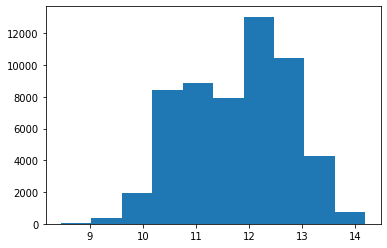

In [18]:
plt.hist(mvir_flag[mvir_flag>0])

(array([1092., 8159., 8472., 8042., 9707., 7179., 3323., 1103.,  201.,
          27.]),
 array([-2.9702144, -2.4294329, -1.8886511, -1.3478696, -0.807088 ,
        -0.2663064,  0.2744752,  0.8152568,  1.3560383,  1.89682  ,
         2.4376016], dtype=float32),
 <BarContainer object of 10 artists>)

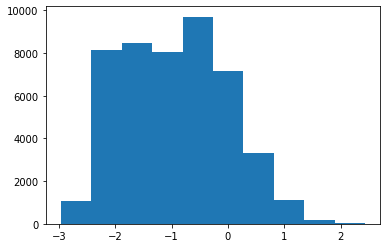

In [24]:
plt.hist(np.log10(sfr_flag[sfr_flag > 0]))

In [35]:
np.sum((subhalos["SubhaloFlag"] == 0) & (subhalos["SubhaloSFR"]>0))/np.sum(subhalos["SubhaloSFR"]>0)

0.026435157166383623